# AG2 Failure Mode Analysis

Load data

In [66]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

DATA_PATH = '../../data/MAST-Data/MAD_full_dataset.json'

with open(DATA_PATH) as f:
    data = json.load(f)

ag2 = [d for d in data if d['mas_name'] == 'AG2']
print(f'Total AG2 traces: {len(ag2)}')
print(f'Benchmarks: {sorted(set(d["benchmark_name"] for d in ag2))}')
print(f'LLMs: {sorted(set(d["llm_name"] for d in ag2))}')

Total AG2 traces: 597
Benchmarks: ['GSM', 'MMLU', 'Olympiad']
LLMs: ['Claude', 'GPT-4o']


In [67]:
# FM labels from the MAST taxonomy
FM_LABELS = {
    '1.1': 'Disobey Task Specification',
    '1.2': 'Disobey Role Specification',
    '1.3': 'Step Repetition',
    '1.4': 'Loss of Conversation History',
    '1.5': 'Unaware of Termination Conditions',
    '2.1': 'Conversation Reset',
    '2.2': 'Fail to Ask for Clarification',
    '2.3': 'Task Derailment',
    '2.4': 'Information Withholding',
    '2.5': 'Ignored Other Agent\'s Input',
    '2.6': 'Reasoning-Action Mismatch',
    '3.1': 'Premature Termination',
    '3.2': 'No or Incomplete Verification',
    '3.3': 'Incorrect Verification',
}
FM_KEYS = list(FM_LABELS.keys())

# Build flat DataFrame
rows = []
for d in ag2:
    row = {
        'benchmark': d['benchmark_name'],
        'llm': d['llm_name'],
        'trace_id': d['trace_id'],
    }
    row.update(d['mast_annotation'])
    rows.append(row)

df = pd.DataFrame(rows)
df.head()

,benchmark,llm,trace_id,1.1,1.2,1.3,1.4,1.5,2.1,2.2,2.3,2.4,2.5,2.6,3.1,3.2,3.3
0,GSM,GPT-4o,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,GSM,GPT-4o,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,GSM,GPT-4o,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,GSM,GPT-4o,3,0,0,0,0,0,0,1,1,0,0,0,0,0,0
4,GSM,GPT-4o,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 1. Overall FM prevalence

In [68]:
total = len(df)

overall = pd.DataFrame({
    'FM': FM_KEYS,
    'Label': [FM_LABELS[k] for k in FM_KEYS],
    'Count': [int(df[k].sum()) for k in FM_KEYS],
})
overall['Prevalence (%)'] = (overall['Count'] / total * 100).round(1)
overall = overall.set_index('FM')

print(f'N = {total} AG2 traces\n')
print(overall.to_string())

N = 597 AG2 traces

                                 Label  Count  Prevalence (%)
FM                                                           
1.1         Disobey Task Specification    193            32.3
1.2         Disobey Role Specification      8             1.3
1.3                    Step Repetition    232            38.9
1.4       Loss of Conversation History     45             7.5
1.5  Unaware of Termination Conditions    177            29.6
2.1                 Conversation Reset     30             5.0
2.2      Fail to Ask for Clarification    170            28.5
2.3                    Task Derailment    129            21.6
2.4            Information Withholding     21             3.5
2.5        Ignored Other Agent's Input      0             0.0
2.6          Reasoning-Action Mismatch    295            49.4
3.1              Premature Termination    134            22.4
3.2      No or Incomplete Verification    112            18.8
3.3             Incorrect Verification    128     

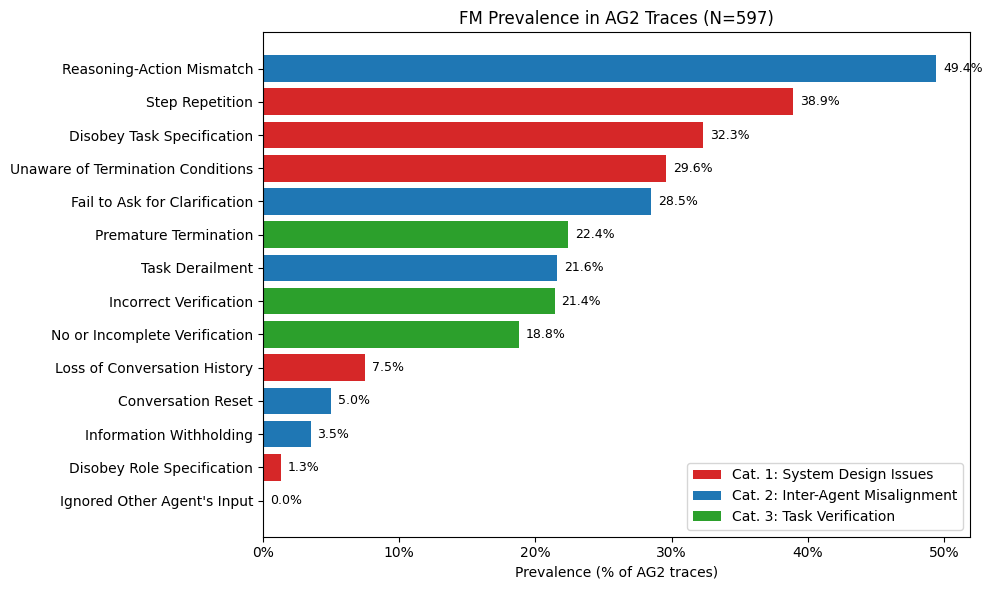

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))

sorted_overall = overall.sort_values('Prevalence (%)', ascending=True)
colors = ['#d62728' if k.startswith('1') else '#1f77b4' if k.startswith('2') else '#2ca02c'
          for k in sorted_overall.index]

bars = ax.barh(sorted_overall['Label'], sorted_overall['Prevalence (%)'], color=colors)
ax.set_xlabel('Prevalence (% of AG2 traces)')
ax.set_title(f'FM Prevalence in AG2 Traces (N={total})')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

for bar, val in zip(bars, sorted_overall['Prevalence (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='Cat. 1: System Design Issues'),
    Patch(facecolor='#1f77b4', label='Cat. 2: Inter-Agent Misalignment'),
    Patch(facecolor='#2ca02c', label='Cat. 3: Task Verification'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('fig_ag2_overall_prevalence.png', dpi=150)
plt.show()

## 2. Breakdown by benchmark

In [70]:
benchmarks = sorted(df['benchmark'].unique())
bench_sizes = df.groupby('benchmark').size().to_dict()

bench_pct = pd.DataFrame(index=FM_KEYS, columns=benchmarks)

for b in benchmarks:
    sub = df[df['benchmark'] == b]
    n = len(sub)
    for fm in FM_KEYS:
        bench_pct.loc[fm, b] = round(sub[fm].sum() / n * 100, 1)

bench_pct.index = [f"{k} {FM_LABELS[k]}" for k in FM_KEYS]
bench_pct = bench_pct.astype(float)

print('Benchmark sizes:', bench_sizes)
print()
print(bench_pct.to_string())

Benchmark sizes: {'GSM': 223, 'MMLU': 168, 'Olympiad': 206}

                                        GSM  MMLU  Olympiad
1.1 Disobey Task Specification         30.9  34.5      32.0
1.2 Disobey Role Specification          1.3   1.2       1.5
1.3 Step Repetition                    37.2  36.3      42.7
1.4 Loss of Conversation History        6.7   4.8      10.7
1.5 Unaware of Termination Conditions  27.4  29.2      32.5
2.1 Conversation Reset                  4.5   3.0       7.3
2.2 Fail to Ask for Clarification      26.5  28.6      30.6
2.3 Task Derailment                    20.2  19.6      24.8
2.4 Information Withholding             3.1   2.4       4.9
2.5 Ignored Other Agent's Input         0.0   0.0       0.0
2.6 Reasoning-Action Mismatch          47.1  47.6      53.4
3.1 Premature Termination              22.0  20.8      24.3
3.2 No or Incomplete Verification      17.9  17.9      20.4
3.3 Incorrect Verification             21.5  20.8      21.8


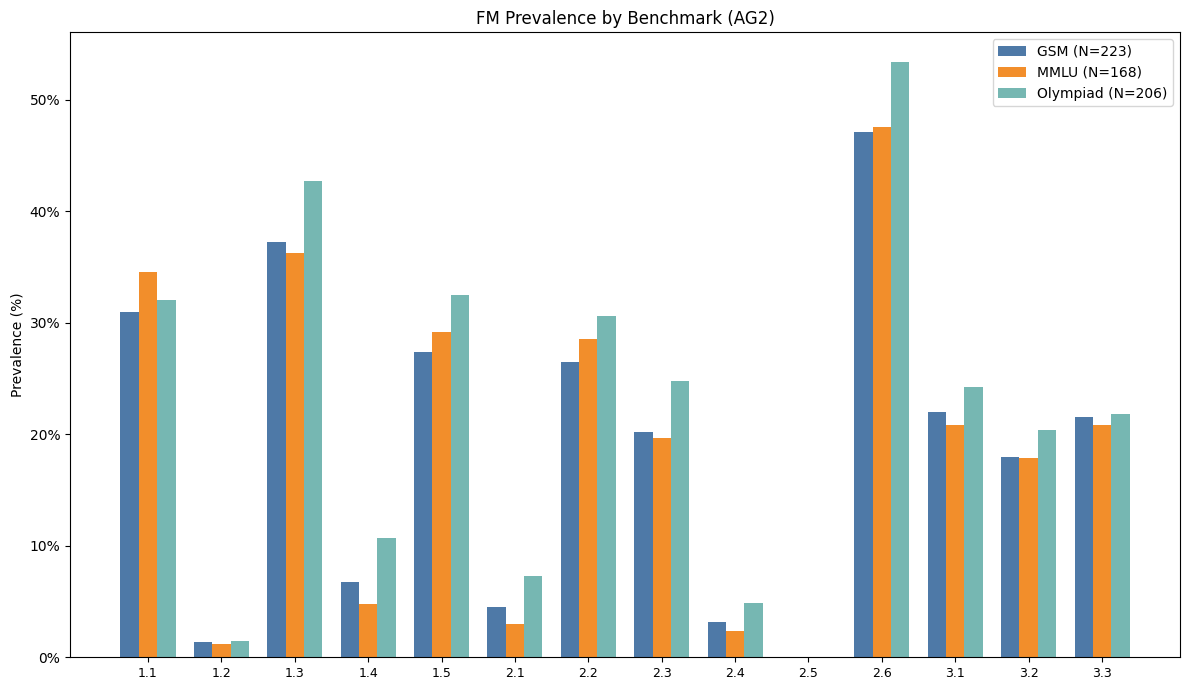

In [71]:
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(FM_KEYS))
width = 0.25
bench_colors = ['#4e79a7', '#f28e2b', '#76b7b2']

for i, (b, color) in enumerate(zip(benchmarks, bench_colors)):
    sub = df[df['benchmark'] == b]
    n = len(sub)
    vals = [sub[fm].sum() / n * 100 for fm in FM_KEYS]
    ax.bar(x + i * width, vals, width, label=f'{b} (N={n})', color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(FM_KEYS, fontsize=9)
ax.set_ylabel('Prevalence (%)')
ax.set_title('FM Prevalence by Benchmark (AG2)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.savefig('fig_ag2_by_benchmark.png', dpi=150)
plt.show()

## 3. Breakdown by LLM

In [72]:
llms = sorted(df['llm'].unique())
llm_sizes = df.groupby('llm').size().to_dict()

llm_pct = pd.DataFrame(index=FM_KEYS, columns=llms)

for l in llms:
    sub = df[df['llm'] == l]
    n = len(sub)
    for fm in FM_KEYS:
        llm_pct.loc[fm, l] = round(sub[fm].sum() / n * 100, 1)

llm_pct.index = [f"{k} {FM_LABELS[k]}" for k in FM_KEYS]
llm_pct = llm_pct.astype(float)

print('LLM sizes:', llm_sizes)
print()
print(llm_pct.to_string())

LLM sizes: {'Claude': 193, 'GPT-4o': 404}

                                       Claude  GPT-4o
1.1 Disobey Task Specification           32.1    32.4
1.2 Disobey Role Specification            1.6     1.2
1.3 Step Repetition                      39.9    38.4
1.4 Loss of Conversation History          7.3     7.7
1.5 Unaware of Termination Conditions    30.6    29.2
2.1 Conversation Reset                    4.7     5.2
2.2 Fail to Ask for Clarification        29.5    28.0
2.3 Task Derailment                      22.3    21.3
2.4 Information Withholding               3.1     3.7
2.5 Ignored Other Agent's Input           0.0     0.0
2.6 Reasoning-Action Mismatch            52.3    48.0
3.1 Premature Termination                24.9    21.3
3.2 No or Incomplete Verification        19.2    18.6
3.3 Incorrect Verification               21.2    21.5


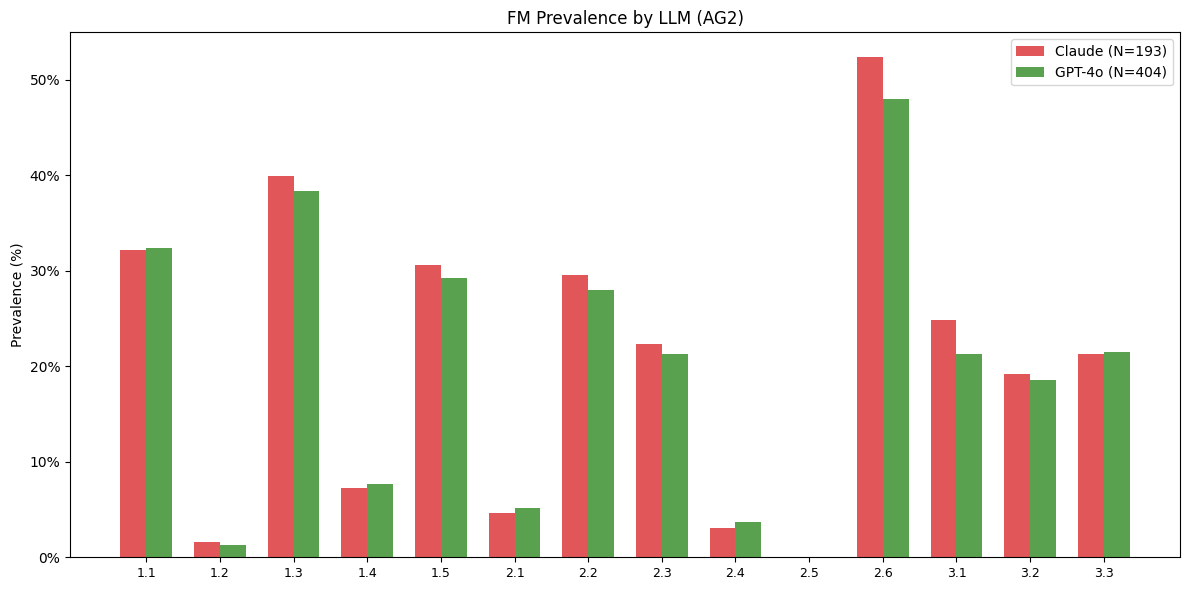

In [73]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(FM_KEYS))
width = 0.35
llm_colors = ['#e15759', '#59a14f']

for i, (l, color) in enumerate(zip(llms, llm_colors)):
    sub = df[df['llm'] == l]
    n = len(sub)
    vals = [sub[fm].sum() / n * 100 for fm in FM_KEYS]
    ax.bar(x + i * width, vals, width, label=f'{l} (N={n})', color=color)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(FM_KEYS, fontsize=9)
ax.set_ylabel('Prevalence (%)')
ax.set_title('FM Prevalence by LLM (AG2)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.savefig('fig_ag2_by_llm.png', dpi=150)
plt.show()

## 5. FM prevalence across all frameworks

### Heatmap all 7 frameworks: reveals duplicate annotations visually

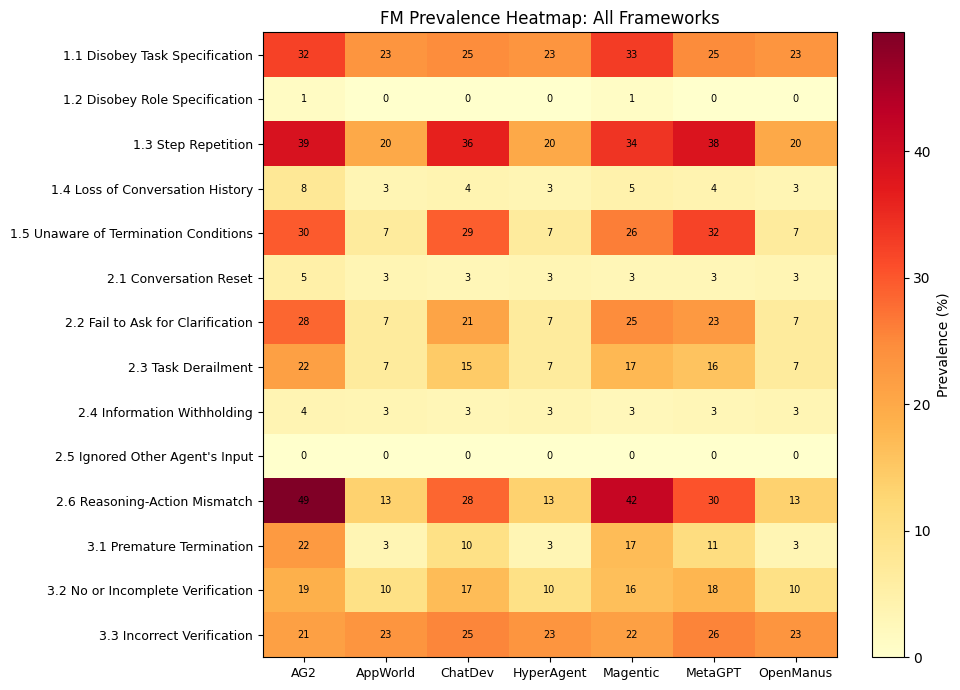

In [74]:
# Load full dataset (all frameworks)
with open(DATA_PATH) as f:
    all_data = json.load(f)

frameworks = sorted(set(d['mas_name'] for d in all_data))
fw_sizes = {f: sum(1 for d in all_data if d['mas_name'] == f) for f in frameworks}

fw_pct = pd.DataFrame(index=FM_KEYS, columns=frameworks, dtype=float)
for fw in frameworks:
    subset = [d for d in all_data if d['mas_name'] == fw]
    n = len(subset)
    for fm in FM_KEYS:
        fw_pct.loc[fm, fw] = sum(d['mast_annotation'].get(fm, 0) for d in subset) / n * 100

fig, ax = plt.subplots(figsize=(10, 7))
n_fw = len(frameworks)
im = ax.imshow(fw_pct.values.astype(float), aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(n_fw))
ax.set_xticklabels(frameworks, fontsize=9)
ax.set_yticks(range(len(FM_KEYS)))
ax.set_yticklabels([f'{k} {FM_LABELS[k]}' for k in FM_KEYS], fontsize=9)
plt.colorbar(im, ax=ax, label='Prevalence (%)')
for i in range(len(FM_KEYS)):
    for j in range(n_fw):
        val = fw_pct.iloc[i, j]
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=7,
                color='white' if val > 50 else 'black')
ax.set_title('FM Prevalence Heatmap: All Frameworks')
plt.tight_layout()
plt.savefig('fig_all_frameworks_heatmap.png', dpi=150)
plt.show()

### FM prevalence heatmap excluding duplicates: actual cross-framework comparison

In [75]:
deduped_frameworks = [fw for fw in frameworks if fw not in ('HyperAgent', 'OpenManus', 'AppWorld')]

table2 = fw_pct[deduped_frameworks].astype(float).round(1)
table2.columns = [fw + ' (N=' + str(fw_sizes[fw]) + ')' for fw in deduped_frameworks]
table2['Spread (std %)'] = table2.std(axis=1).round(1)
(
    table2.style
    .background_gradient(cmap='YlOrRd', subset=list(table2.columns[:-1]), axis=None)
    .background_gradient(cmap='Purples', subset=['Spread (std %)'], axis=0)
)

,AG2 (N=597),ChatDev (N=130),Magentic (N=195),MetaGPT (N=230),Spread (std %)
1.1,32.300000,24.600000,32.800000,24.800000,4.500000
1.2,1.300000,0.000000,1.000000,0.000000,0.700000
1.3,38.900000,36.200000,33.800000,38.300000,2.300000
1.4,7.500000,3.800000,4.600000,3.900000,1.700000
1.5,29.600000,29.200000,26.200000,32.200000,2.500000
2.1,5.000000,3.100000,3.100000,3.000000,1.000000
2.2,28.500000,20.800000,24.600000,22.600000,3.300000
2.3,21.600000,14.600000,17.400000,15.700000,3.100000
2.4,3.500000,3.100000,2.600000,3.000000,0.400000
2.5,0.000000,0.000000,0.000000,0.000000,0.000000


### FM rank table with spread: shows which FMs are framework-specific

In [76]:
ranked = table2.iloc[:, :-1].rank(ascending=False, method='min').astype(int)
ranked['Rank spread (std)'] = ranked.std(axis=1).round(0).astype(int)
(
    ranked.style
    .background_gradient(cmap='RdYlGn_r', subset=list(ranked.columns[:-1]), axis=0)
    .background_gradient(cmap='Purples', subset=['Rank spread (std)'], axis=0)
)

,AG2 (N=597),ChatDev (N=130),Magentic (N=195),MetaGPT (N=230),Rank spread (std)
1.1,3,5,3,5,1
1.2,13,13,13,13,0
1.3,2,1,2,1,1
1.4,10,10,10,10,0
1.5,4,2,4,2,1
2.1,11,11,11,11,0
2.2,5,6,5,6,1
2.3,7,8,7,8,1
2.4,12,11,12,11,1
2.5,14,13,14,13,1


## 6. Annotation analysis

In [ ]:
from collections import Counter, defaultdict

id_records = defaultdict(list)
for d in all_data:
    id_records[d['trace_id']].append(d)

total = len(all_data)
distinct = len(id_records)
dup_ids = {tid: recs for tid, recs in id_records.items() if len(recs) > 1}
truly_unique = distinct - len(dup_ids)

identical = sum(
    1 for recs in dup_ids.values()
    if len(set(str(r['mast_annotation']) for r in recs)) == 1
)
pct_identical = identical / len(dup_ids) * 100

print(f'Total records:                    {total:>5}')
print(f'Distinct trace_ids:               {distinct:>5}')
print(f'trace_ids appearing >1x:          {len(dup_ids):>5}  ({pct_identical:.1f}% have identical annotation)')
print(f'trace_ids appearing exactly once: {truly_unique:>5}')

Total records:                     1242
Distinct trace_ids:                 206
trace_ids appearing >1x:            193  (100.0% have identical annotation)
trace_ids appearing exactly once:    13
